In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)

In [3]:
%pip install l0bnb

Note: you may need to restart the kernel to use updated packages.


In [4]:
from l0bnb import fit_path

In [5]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

In [6]:
Hitters = Hitters.dropna();
Hitters.shape

(263, 20)

In [7]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

In [8]:
design = MS(Hitters.columns.drop('Salary')).fit(Hitters)

Y = np.array(Hitters['Salary'])

X = design.transform(Hitters)

sigma2 = OLS(Y,X).fit().scale

In [9]:
neg_Cp = partial(nCp, sigma2)

In [10]:
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))

In [11]:
hitters_MSE = sklearn_selected(OLS,
                               strategy)

hitters_MSE.fit(Hitters, Y)

hitters_MSE.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Errors',
 'Hits',
 'HmRun',
 'League',
 'NewLeague',
 'PutOuts',
 'RBI',
 'Runs',
 'Walks',
 'Years')

In [12]:
hitters_Cp = sklearn_selected(OLS,
                              strategy,
                              scoring=neg_Cp)

hitters_Cp.fit(Hitters, Y)

hitters_Cp.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

In [13]:
strategy = Stepwise.fixed_steps(design,
                                len(design.terms),
                                direction='forward')

full_path = sklearn_selection_path(OLS, strategy)

In [14]:
full_path.fit(Hitters, Y)

Yhat_in = full_path.predict(Hitters)

Yhat_in.shape

(263, 20)

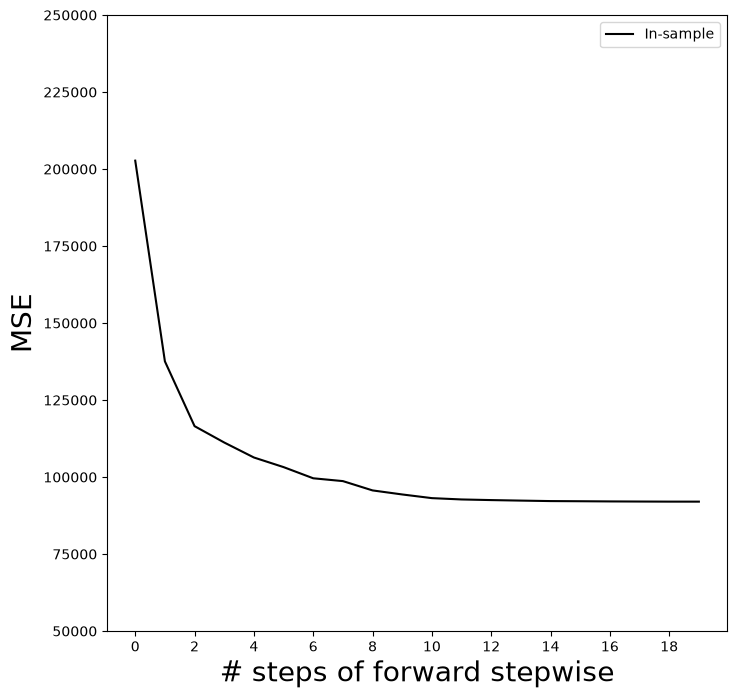

In [15]:
mse_fig, ax = subplots(figsize=(8,8))

insample_mse = ((Yhat_in - Y[:,None])**2).mean(0)

n_steps = insample_mse.shape[0]

ax.plot(np.arange(n_steps),
        insample_mse,
        'k',
        label='In-sample')

ax.set_ylabel('MSE',
              fontsize=20)

ax.set_xlabel('# steps of forward stepwise',
              fontsize=20)

ax.set_xticks(np.arange(n_steps)[::2])

ax.legend()

ax.set_ylim([50000,250000]);

In [16]:
K=5

kfold = skm.KFold(K,
                  random_state=0,
                  shuffle=True)

Yhat_cv = skm.cross_val_predict(full_path,
                                Hitters,
                                Y,
                                cv=kfold)

Yhat_cv.shape

(263, 20)

In [17]:
cv_mse = []

for train_idx, test_idx in kfold.split(Y):
    errors = (Yhat_cv[test_idx] - Y[test_idx,None])**2
    cv_mse.append(errors.mean(0))

cv_mse = np.array(cv_mse).T

cv_mse.shape

(20, 5)

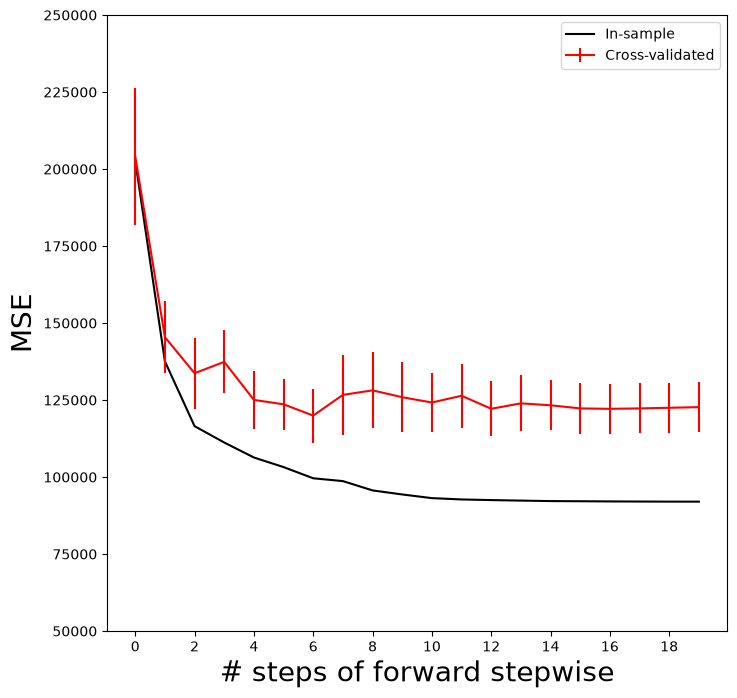

In [18]:
ax.errorbar(np.arange(n_steps),
            cv_mse.mean(1),
            cv_mse.std(1) / np.sqrt(K),
            label='Cross-validated',
            c='r')

ax.set_ylim([50000,250000])

ax.legend()

mse_fig

In [19]:
validation = skm.ShuffleSplit(n_splits=1,
                              test_size=0.2,
                              random_state=0)

for train_idx, test_idx in validation.split(Y):
    full_path.fit(Hitters.iloc[train_idx],
                  Y[train_idx])

    Yhat_val = full_path.predict(Hitters.iloc[test_idx])

    errors = (Yhat_val - Y[test_idx,None])**2

    validation_mse = errors.mean(0)

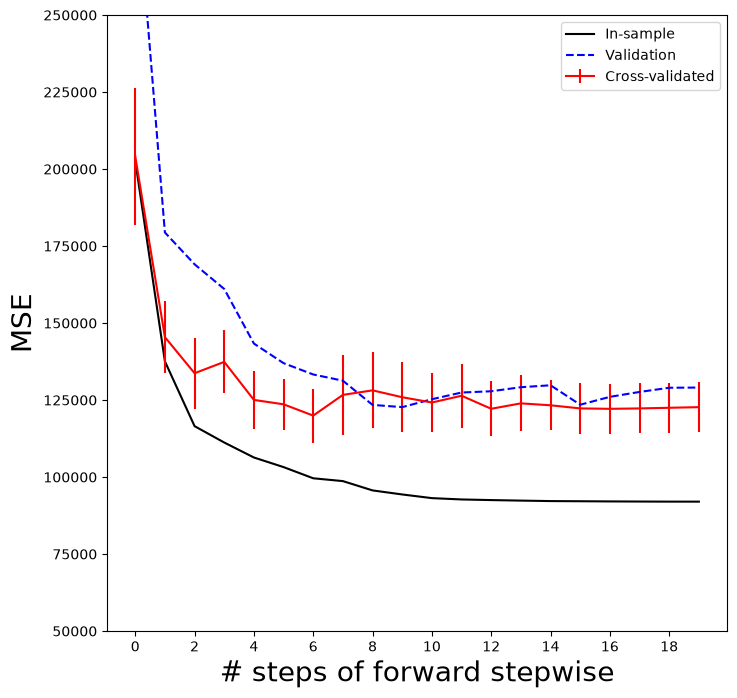

In [20]:
ax.plot(np.arange(n_steps),
        validation_mse,
        'b--',
        label='Validation')

ax.set_xticks(np.arange(n_steps)[::2])

ax.set_ylim([50000,250000])

ax.legend()

mse_fig

In [21]:
D = design.fit_transform(Hitters)

D = D.drop('intercept', axis=1)

X = np.asarray(D)

In [22]:
np.Inf = np.inf

In [23]:
path = fit_path(X,
                Y,
                max_nonzeros=X.shape[1])

Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  2
Iteration: 3. Number of non-zeros:  2
Iteration: 4. Number of non-zeros:  2
Iteration: 5. Number of non-zeros:  3
Iteration: 6. Number of non-zeros:  3
Iteration: 7. Number of non-zeros:  4
Iteration: 8. Number of non-zeros:  9
Iteration: 9. Number of non-zeros:  9
Iteration: 10. Number of non-zeros:  9
Iteration: 11. Number of non-zeros:  9
Iteration: 12. Number of non-zeros:  9
Iteration: 13. Number of non-zeros:  9
Iteration: 14. Number of non-zeros:  9
Iteration: 15. Number of non-zeros:  9
Iteration: 16. Number of non-zeros:  9
Iteration: 17. Number of non-zeros:  9
Iteration: 18. Number of non-zeros:  17
Iteration: 19. Number of non-zeros:  19


In [24]:
path[3]

{'B': array([0.        , 3.25484367, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.67775265, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'B0': np.float64(-38.98216739555505),
 'lambda_0': np.float64(0.011416248027450187),
 'M': np.float64(0.5829861733382012),
 'Time_exceeded': False}

In [25]:
Xs = X - X.mean(0)[None,:]
X_scale = X.std(0)
Xs = Xs / X_scale[None,:]

lambdas = 10**np.linspace(8, -2, 100) / Y.std()

soln_array = skl.ElasticNet.path(Xs,
                                 Y,
                                 l1_ratio=0.,
                                 alphas=lambdas)[1]

soln_array.shape

(19, 100)

In [26]:
soln_path = pd.DataFrame(soln_array.T,
                         columns=D.columns,
                         index=-np.log(lambdas))

soln_path.index.name = 'negative log(lambda)'

soln_path

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League[N],Division[W],PutOuts,Assists,Errors,NewLeague[N]
negative log(lambda),,,,,,,,,,,,,,,,,,,
-12.310855,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-12.078271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.845686,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.613102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.380518,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9.784658,-289.996568,334.900335,36.473153,-58.501790,-25.719708,134.573060,-16.888219,-396.132234,107.742403,-7.075781,468.492732,248.849471,-211.631278,31.412861,-58.462157,78.751831,53.842150,-22.342587,-12.586958
10.017243,-290.029450,335.162913,36.658484,-58.750152,-25.897874,134.620003,-16.741406,-396.772560,106.230133,-7.887377,470.000000,250.268837,-211.834906,31.403306,-58.451212,78.748866,53.859095,-22.325593,-12.563830
10.249827,-290.067133,335.397862,36.815896,-58.963198,-26.048751,134.661168,-16.630426,-397.162849,104.792702,-8.595946,471.291473,251.498935,-212.016626,31.393726,-58.442527,78.746696,53.869499,-22.310387,-12.543160


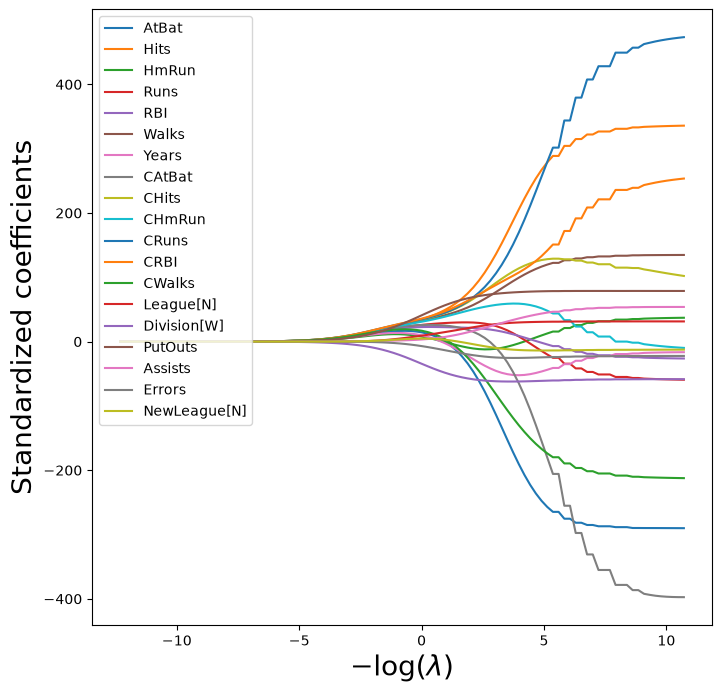

In [27]:
path_fig, ax = subplots(figsize=(8,8))

soln_path.plot(ax=ax, legend=False)

ax.set_xlabel('$-\log(\lambda)$', fontsize=20)

ax.set_ylabel('Standardized coefficients', fontsize=20)

ax.legend(loc='upper left');

In [28]:
beta_hat = soln_path.loc[soln_path.index[39]]

lambdas[39], beta_hat

(np.float64(25.53538897200662),
 AtBat           5.433750
 Hits            6.223581
 HmRun           4.585497
 Runs            5.880855
 RBI             6.195921
 Walks           6.277974
 Years           5.299766
 CAtBat          7.147501
 CHits           7.539495
 CHmRun          7.182344
 CRuns           7.728649
 CRBI            7.790702
 CWalks          6.592901
 League[N]       0.042445
 Division[W]    -3.107159
 PutOuts         4.605263
 Assists         0.378371
 Errors         -0.135196
 NewLeague[N]    0.150323
 Name: -3.240065292879872, dtype: float64)

In [29]:
np.linalg.norm(beta_hat)

np.float64(24.170616077668743)

In [30]:
beta_hat = soln_path.loc[soln_path.index[59]]

lambdas[59], np.linalg.norm(beta_hat)

(np.float64(0.24374766133488554), np.float64(160.43614214007252))

In [31]:
ridge = skl.ElasticNet(alpha=lambdas[59],
                       l1_ratio=0)

scaler = StandardScaler(with_mean=True,
                        with_std=True)

pipe = Pipeline(steps=[('scaler', scaler),
                       ('ridge', ridge)])

pipe.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


In [32]:
np.linalg.norm(ridge.coef_)

np.float64(160.41661128089146)

In [33]:
validation = skm.ShuffleSplit(n_splits=1,
                              test_size=0.5,
                              random_state=0)

ridge.alpha = 0.01

results = skm.cross_validate(ridge,
                             X,
                             Y,
                             scoring='neg_mean_squared_error',
                             cv=validation)

-results['test_score']

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.503175e+07, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


array([134214.00419204])

In [34]:
ridge.alpha = 1e10

results = skm.cross_validate(ridge,
                             X,
                             Y,
                             scoring='neg_mean_squared_error',
                             cv=validation)

-results['test_score']

array([231853.41506334])

In [35]:
param_grid = {'ridge__alpha': lambdas}

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=validation,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)

grid.best_params_['ridge__alpha']

grid.best_estimator_

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.422292e+03, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.331964e+03, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficientl

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


In [36]:
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)

grid.best_params_['ridge__alpha']

grid.best_estimator_

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.696588e+03, tolerance: 4.466e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.044553e+03, tolerance: 4.437e+03
Linear regression models with a zero l1 penalization strength are more efficientl

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


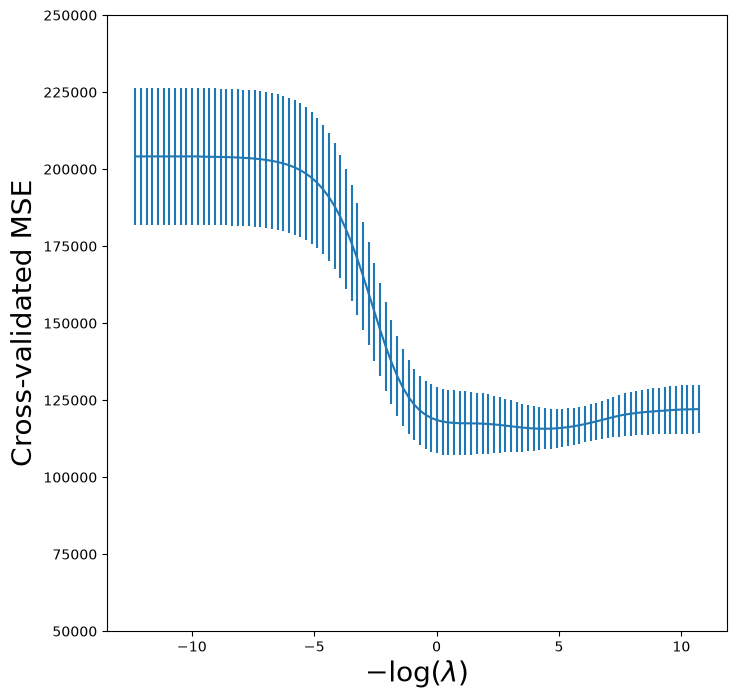

In [37]:
ridge_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))

ax.set_ylim([50000,250000])

ax.set_xlabel('$-\log(\lambda)$', fontsize=20)

ax.set_ylabel('Cross-validated MSE', fontsize=20);

In [38]:
grid_r2 = skm.GridSearchCV(pipe,
                           param_grid,
                           cv=kfold)

grid_r2.fit(X, Y)

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.696588e+03, tolerance: 4.466e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.044553e+03, tolerance: 4.437e+03
Linear regression models with a zero l1 penalization strength are more efficientl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...l1_ratio=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([2.2209...22093791e-05])}
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

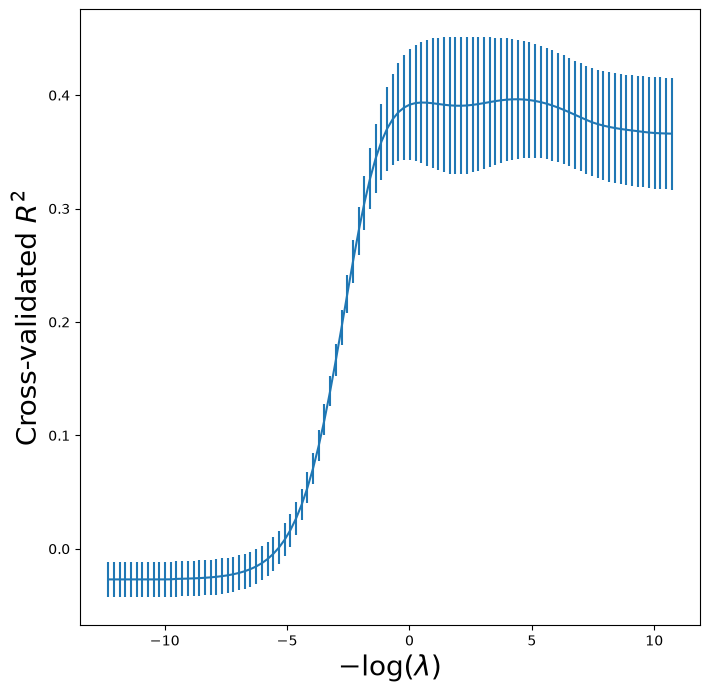

In [39]:
r2_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log(lambdas),
            grid_r2.cv_results_['mean_test_score'],
            yerr=grid_r2.cv_results_['std_test_score'] / np.sqrt(K))

ax.set_xlabel('$-\log(\lambda)$', fontsize=20)

ax.set_ylabel('Cross-validated $R^2$', fontsize=20);

In [40]:
ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                           l1_ratio=0,
                           cv=kfold)

pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('ridge', ridgeCV)])

pipeCV.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


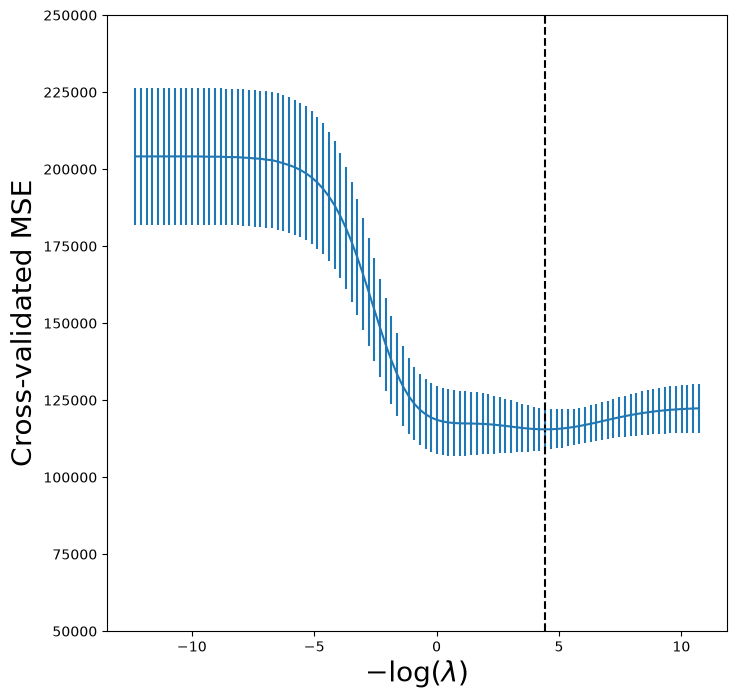

In [41]:
tuned_ridge = pipeCV.named_steps['ridge']

ridgeCV_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log(lambdas),
            tuned_ridge.mse_path_.mean(1),
            yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_ridge.alpha_),
           c='k',
           ls='--')

ax.set_ylim([50000,250000])

ax.set_xlabel('$-\log(\lambda)$',
              fontsize=20)

ax.set_ylabel('Cross-validated MSE',
              fontsize=20);

In [42]:
np.min(tuned_ridge.mse_path_.mean(1))

np.float64(115519.65106973323)

In [43]:
tuned_ridge.coef_

array([-222.89879608,  238.75984009,    3.19940859,   -2.78622901,
          3.65641889,  108.90696355,  -50.99835353, -103.8607335 ,
        121.8831849 ,   57.24126481,  209.34371641,  117.88285202,
       -150.10311712,   30.35774054,  -61.64169747,   77.73148598,
         40.04131722,  -25.02859526,  -13.69424589])

In [44]:
outer_valid = skm.ShuffleSplit(n_splits=1,
                               test_size=0.25,
                               random_state=1)

inner_cv = skm.KFold(n_splits=5,
                     shuffle=True,
                     random_state=2)

ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                           l1_ratio=0,
                           cv=inner_cv)

pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('ridge', ridgeCV)]);

In [45]:
results = skm.cross_validate(pipeCV,
                             X,
                             Y,
                             cv=outer_valid,
                             scoring='neg_mean_squared_error')

-results['test_score']

array([132393.96280408])

In [46]:
lassoCV = skl.ElasticNetCV(alphas=lambdas,
                           l1_ratio=1,
                           cv=kfold)

pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('lasso', lassoCV)])

pipeCV.fit(X, Y)

tuned_lasso = pipeCV.named_steps['lasso']

tuned_lasso.alpha_

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.246185e+03, tolerance: 4.201e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.283060e+03, tolerance: 4.201e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to incre

np.float64(3.148122103452325)

In [47]:
lambdas, soln_array = skl.Lasso.path(Xs,
                                     Y,
                                     l1_ratio=1,
                                     n_alphas=100)[:2]

soln_path = pd.DataFrame(soln_array.T,
                         columns=D.columns,
                         index=-np.log(lambdas))

c:\Users\DZAQRJE\Downloads\Chap 2&3 Exercises Data Mining\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:637: FutureWarning: 'n_alphas' was deprecated in 1.9 and will be removed in 1.11. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.11. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


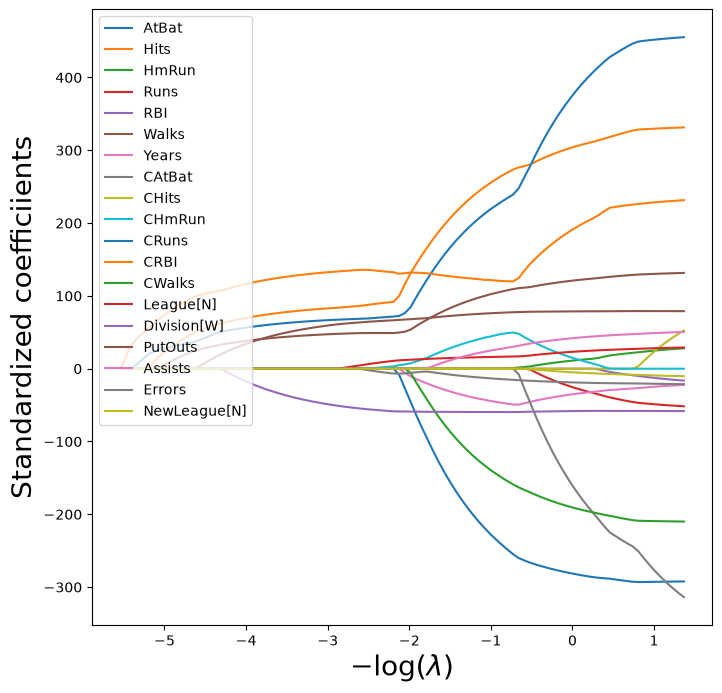

In [48]:
path_fig, ax = subplots(figsize=(8,8))

soln_path.plot(ax=ax, legend=False)

ax.legend(loc='upper left')

ax.set_xlabel('$-\log(\lambda)$',
              fontsize=20)

ax.set_ylabel('Standardized coefficiients',
              fontsize=20);

In [49]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(114675.60007519818)

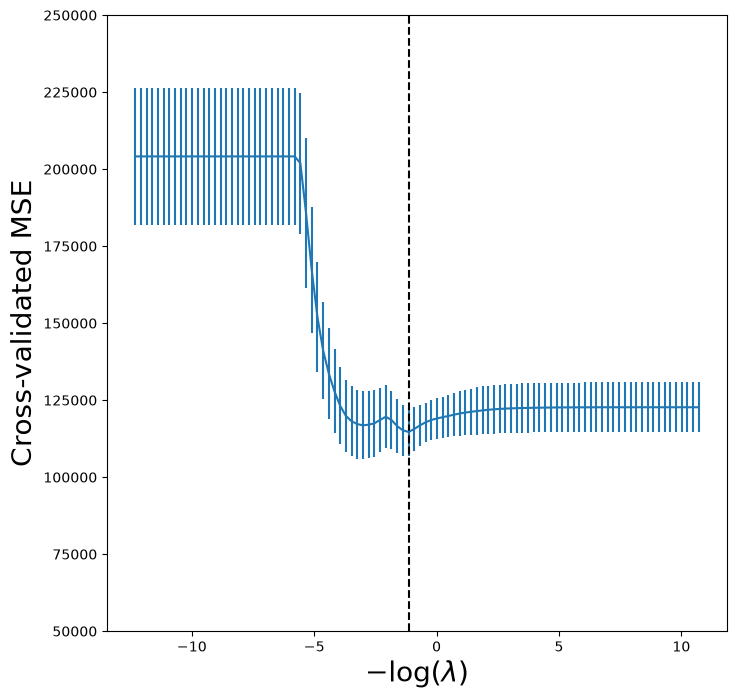

In [50]:
lassoCV_fig, ax = subplots(figsize=(8,8))

ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_lasso.alpha_),
           c='k',
           ls='--')

ax.set_ylim([50000,250000])

ax.set_xlabel('$-\log(\lambda)$',
              fontsize=20)

ax.set_ylabel('Cross-validated MSE',
              fontsize=20);

In [51]:
tuned_lasso.coef_

array([-209.97374999,  243.43053991,    0.        ,    0.        ,
          0.        ,   97.68430954,  -41.51608098,   -0.        ,
          0.        ,   39.6150143 ,  205.72600181,  124.55685811,
       -126.27309456,   15.70190319,  -59.50148285,   75.24404735,
         21.62024513,  -12.04162566,   -0.        ])

In [52]:
pca = PCA(n_components=2)

linreg = skl.LinearRegression()

pipe = Pipeline([('pca', pca),
                 ('linreg', linreg)])

pipe.fit(X, Y)

pipe.named_steps['linreg'].coef_

array([0.09846131, 0.4758765 ])

In [53]:
pipe = Pipeline([('scaler', scaler),
                 ('pca', pca),
                 ('linreg', linreg)])

pipe.fit(X, Y)

pipe.named_steps['linreg'].coef_

array([106.36859204,  21.60350456])

In [54]:
param_grid = {'pca__n_components': range(1, 20)}

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

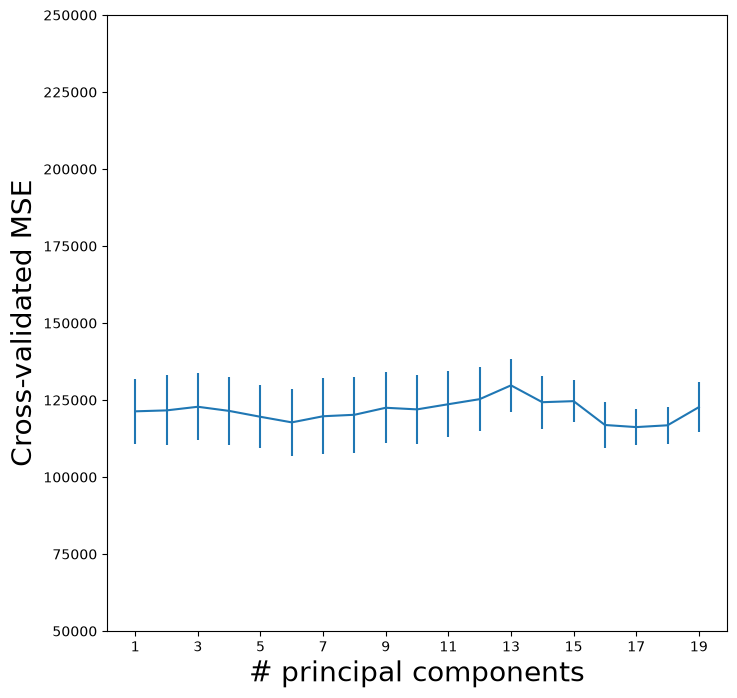

In [55]:
pcr_fig, ax = subplots(figsize=(8,8))

n_comp = param_grid['pca__n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))

ax.set_ylabel('Cross-validated MSE', fontsize=20)

ax.set_xlabel('# principal components', fontsize=20)

ax.set_xticks(n_comp[::2])

ax.set_ylim([50000,250000]);

In [56]:
Xn = np.zeros((X.shape[0], 1))

cv_null = skm.cross_validate(linreg,
                             Xn,
                             Y,
                             cv=kfold,
                             scoring='neg_mean_squared_error')

-cv_null['test_score'].mean()

np.float64(204139.30692994667)

In [57]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.3831424 , 0.21841076])

In [58]:
pls = PLSRegression(n_components=2,
                    scale=True)

pls.fit(X, Y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](1, 19)","[[ 0.18, 0.97, 1.43,..., 0.03,-0.66,30.21]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](1,)",[535.93]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,19
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,"[1, 1]"
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](19, 2)","[[ 0.23, 0.35], [ 0.22, 0.36], [ 0.22, 0.09], ..., [ 0.01, 0.13], [ 0. , 0.16], [-0.03, 0.31]]"


In [59]:
param_grid = {'n_components':range(1, 20)}

grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PLSRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

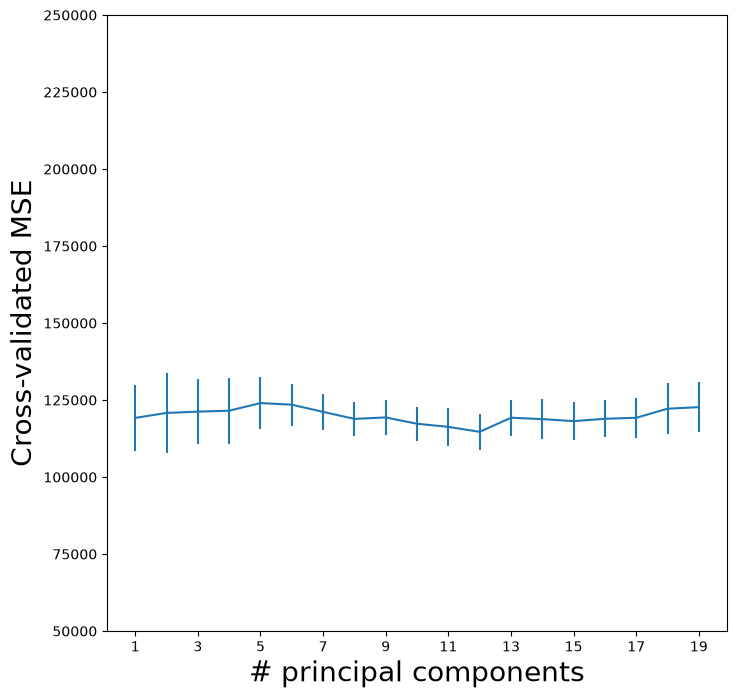

In [60]:
pls_fig, ax = subplots(figsize=(8,8))

n_comp = param_grid['n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))

ax.set_ylabel('Cross-validated MSE', fontsize=20)

ax.set_xlabel('# principal components', fontsize=20)

ax.set_xticks(n_comp[::2])

ax.set_ylim([50000,250000]);